# Multi-Agente Cooperativo en Overcooked con MAPPO

**Entorno:** [Overcooked-AI](https://github.com/HumanCompatibleAI/overcooked_ai) (Berkeley HCAI)
**Algoritmo:** MAPPO (Multi-Agent PPO) con *parameter sharing* y *Centralised Training, Decentralised Execution* (CTDE)
**Framework:** Ray RLlib
**Layout:** `forced_coordination` — los dos cocineros están físicamente separados y **obligados** a pasarse ingredientes por el mostrador del medio. Cualquier sopa entregada es prueba directa de cooperación.

---

## Objetivo del notebook
Mostrar de la forma más práctica posible **cómo se implementa y entrena un sistema multiagente cooperativo**: dos agentes que aprenden, sin comunicación explícita, a coordinarse para preparar y servir sopa de cebolla en una cocina al estilo *Overcooked*.

Todo el contenido vive en un único notebook, sin código duplicado, reutilizando el entorno y el visualizador ya implementados por Overcooked-AI.


### 1. Sistemas multiagente (MAS)
Un **Multi-Agent System** está compuesto por varios agentes autónomos que comparten un entorno y toman decisiones simultáneamente. Se clasifican según la estructura de recompensas:

| Tipo | Recompensas | Ejemplo |
|---|---|---|
| **Cooperativo** | Compartida entre todos los agentes | Overcooked, robots colaborativos |
| **Competitivo** | Suma cero | Ajedrez, Go |
| **Mixto** | Cooperación dentro de equipos, competición entre equipos | StarCraft, fútbol |

Overcooked es **puramente cooperativo**: los dos cocineros reciben la misma recompensa global (+20) cada vez que el equipo entrega una sopa, sin importar quién hizo qué.

### 2. ¿Por qué no entrenar dos PPO independientes?
Si cada agente aprendiese con un PPO propio e ignorase al otro, el entorno aparecería **no estacionario** desde su perspectiva (el otro agente cambia su política durante el entrenamiento), rompiendo las garantías de convergencia de PPO. Además no habría señal estructural para coordinarse.

### 3. MAPPO: PPO multiagente con CTDE
MAPPO ([Yu et al., 2022](https://arxiv.org/abs/2103.01955)) extiende PPO al caso multiagente siguiendo el paradigma **Centralised Training, Decentralised Execution**:

- **Crítico centralizado** (entrenamiento): estima `V(s)` con información global del estado conjunto → ventajas estables.
- **Política descentralizada** (ejecución): cada agente decide solo con su **observación local** → el agente entrenado podría desplegarse en un robot real sin comunicación.

### 4. Parameter sharing
En entornos cooperativos homogéneos como Overcooked, los dos cocineros son intercambiables. Compartir una **única red de política** entre ambos:

1. Reduce a la mitad los parámetros aprendibles.
2. Duplica la eficiencia muestral (cada transición entrena los dos "roles").
3. Induce coordinación implícita: ambos agentes razonan con la misma función.

La observación de cada agente incluye su propia posición en primer plano, así que la misma red puede generar conductas distintas según en qué lado del mostrador esté.

### 5. Estructura del notebook
1. **Instalación e imports** con versiones fijas.
2. **Entorno**: `OvercookedMultiAgentEnv` envolviendo `OvercookedEnv` como `MultiAgentEnv` de RLlib.
3. **Visualización** del layout y el estado inicial.
4. **Configuración MAPPO** con hiperparámetros explicados.
5. **Entrenamiento** + curva de aprendizaje.
6. **Evaluación cuantitativa**: random vs MAPPO (sopas entregadas).
7. **Renderizado a MP4** para ver la cooperación emergente.


In [33]:
!pip -q install "numpy<2"
!pip -q install "ray[rllib]==2.32.0"
!pip -q install "gymnasium==0.29.1"
!pip -q install overcooked-ai
!pip -q install pygame imageio imageio-ffmpeg matplotlib

print("\n>>> Instalación completada.")


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pettingzoo 1.26.1 requires gymnasium>=1.0.0, but you have gymnasium 0.29.1 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; p

## 1. Imports

Importamos las librerías necesarias:

- **Overcooked-AI** (`overcooked_ai_py`): el MDP (`OvercookedGridworld`), el entorno (`OvercookedEnv`), el espacio de acciones (`Action`) y el visualizador (`StateVisualizer`).
- **Ray RLlib**: `PPOConfig` y `MultiAgentEnv` — vamos directo a la interfaz de RLlib **sin** pasar por PettingZoo, lo que elimina problemas de serialización y reduce dependencias.
- **pygame + imageio + matplotlib**: render y exportación a MP4.

`SDL_VIDEODRIVER=dummy` permite que `pygame` rinda en modo *headless* (Colab/servidor sin pantalla).


In [1]:
import os
import sys
import importlib.util

os.environ.setdefault("SDL_VIDEODRIVER", "dummy")

import numpy as np

# ---- shim para el proceso driver (suficiente para el código que corremos aquí)
if not hasattr(np, "Inf"):     np.Inf = np.inf
if not hasattr(np, "NaN"):     np.NaN = np.nan
if not hasattr(np, "product"): np.product = np.prod


def _patch_numpy2(packages=("overcooked_ai_py", "ray"), verbose=True):
    """Reescribe en disco las APIs eliminadas en numpy 2.x dentro de los
    paquetes indicados. Necesario porque los workers de Ray son procesos
    nuevos y leen el código del archivo, no heredan parches del driver.
    Es idempotente (segundo run no hace nada).
    """
    replacements = {
        "np.Inf":         "np.inf",
        "np.NaN":         "np.nan",
        "np.product(":    "np.prod(",
        "numpy.product(": "numpy.prod(",
    }
    total_patched = []
    for pkg in packages:
        spec = importlib.util.find_spec(pkg)
        if spec is None or spec.origin is None:
            if verbose: print(f"  [{pkg}] no encontrado, omitido.")
            continue
        pkg_dir = os.path.dirname(spec.origin)
        patched = []
        for root, _, files in os.walk(pkg_dir):
            for fname in files:
                if not fname.endswith(".py"):
                    continue
                path = os.path.join(root, fname)
                try:
                    with open(path, "r", encoding="utf-8") as f:
                        src = f.read()
                except (UnicodeDecodeError, OSError):
                    continue
                new_src = src
                for old, new in replacements.items():
                    new_src = new_src.replace(old, new)
                if new_src != src:
                    try:
                        with open(path, "w", encoding="utf-8") as f:
                            f.write(new_src)
                        patched.append(path)
                    except OSError:
                        pass
        if verbose:
            print(f"  [{pkg}] parcheados {len(patched)} archivos.")
        total_patched.extend(patched)
        # Limpia caché de módulos del paquete para forzar relectura desde disco
        for modname in list(sys.modules.keys()):
            if modname == pkg or modname.startswith(pkg + "."):
                del sys.modules[modname]
    return total_patched


print("Parcheando paquetes para compatibilidad con numpy 2.x...")
_patch_numpy2()

import pygame
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces

# Overcooked-AI
from overcooked_ai_py.mdp.overcooked_mdp import OvercookedGridworld
from overcooked_ai_py.mdp.overcooked_env import OvercookedEnv
from overcooked_ai_py.mdp.actions import Action
from overcooked_ai_py.visualization.state_visualizer import StateVisualizer

# Ray / RLlib
import ray
from ray.rllib.algorithms.ppo import PPOConfig
from ray.rllib.env.multi_agent_env import MultiAgentEnv
from ray.tune.registry import register_env

# Vídeo
import imageio

SEED = 42
np.random.seed(SEED)
print("\nImports OK. Ray:", ray.__version__, "| numpy:", np.__version__)


pygame 2.6.1 (SDL 2.28.4, Python 3.12.13)
Hello from the pygame community. https://www.pygame.org/contribute.html


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

Imports OK. Ray: 2.32.0 | numpy: 2.4.6


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 2. Entorno multi-agente

Overcooked-AI expone `OvercookedGridworld` (MDP) y `OvercookedEnv` (loop episódico). Para entrenarlo con RLlib lo envolvemos en una subclase de `MultiAgentEnv` con dos agentes (`agent_0`, `agent_1`) que actúan simultáneamente.


In [2]:
LAYOUT_NAME = "forced_coordination"   # cocina dividida -> cooperación obligatoria
HORIZON     = 400                     # pasos máximos por episodio


class OvercookedMultiAgentEnv(MultiAgentEnv):
    """Overcooked-AI como MultiAgentEnv de RLlib (2 cocineros cooperativos)."""

    NUM_ACTIONS = 6
    AGENT_IDS   = ["agent_0", "agent_1"]

    def __init__(self, config=None):
        super().__init__()
        config = config or {}
        self.layout_name = config.get("layout_name", LAYOUT_NAME)
        self.horizon     = config.get("horizon", HORIZON)

        self.mdp        = OvercookedGridworld.from_layout_name(self.layout_name)
        self.base_env   = OvercookedEnv.from_mdp(self.mdp, horizon=self.horizon)
        self.visualizer = StateVisualizer()

        self._agent_ids = set(self.AGENT_IDS)
        sample = self._encode_state()
        obs_shape = sample[0].shape

        single_obs = spaces.Box(low=0.0, high=255.0, shape=obs_shape, dtype=np.float32)
        single_act = spaces.Discrete(self.NUM_ACTIONS)
        self.observation_space = spaces.Dict({a: single_obs for a in self.AGENT_IDS})
        self.action_space      = spaces.Dict({a: single_act for a in self.AGENT_IDS})

    # ---------------- helpers ----------------
    def _encode_state(self):
        state = self.base_env.state
        if hasattr(self.base_env, "lossless_state_encoding_mdp"):
            return self.base_env.lossless_state_encoding_mdp(state)
        return self.mdp.lossless_state_encoding(state, horizon=self.horizon)

    def _get_obs(self):
        enc = self._encode_state()
        return {
            "agent_0": np.asarray(enc[0], dtype=np.float32),
            "agent_1": np.asarray(enc[1], dtype=np.float32),
        }

    def _surface_to_array(self, result):
        if isinstance(result, np.ndarray):
            return result.astype(np.uint8)
        arr = pygame.surfarray.array3d(result)
        return np.transpose(arr, (1, 0, 2))   # (W,H,3) -> (H,W,3)

    # ---------------- MultiAgentEnv API ----------------
    def reset(self, *, seed=None, options=None):
        if seed is not None:
            np.random.seed(seed)
        self.base_env.reset()
        return self._get_obs(), {a: {} for a in self.AGENT_IDS}

    def step(self, action_dict):
        # Overcooked espera tuplas Action; mapeamos los índices.
        a0 = Action.INDEX_TO_ACTION[int(action_dict["agent_0"])]
        a1 = Action.INDEX_TO_ACTION[int(action_dict["agent_1"])]
        next_state, reward, done, info = self.base_env.step((a0, a1))

        shaped = info.get("shaped_r_by_agent", [0.0, 0.0]) if isinstance(info, dict) else [0.0, 0.0]
        rewards = {
            "agent_0": float(reward) + float(shaped[0]),
            "agent_1": float(reward) + float(shaped[1]),
        }
        terms  = {"agent_0": bool(done), "agent_1": bool(done), "__all__": bool(done)}
        truncs = {"agent_0": False,      "agent_1": False,      "__all__": False}
        infos  = {a: dict(info) if isinstance(info, dict) else {} for a in self.AGENT_IDS}
        # Guardamos la sopa entregada (+20 base) para métricas de coordinación.
        infos["agent_0"]["sparse_reward"] = float(reward)
        infos["agent_1"]["sparse_reward"] = float(reward)
        return self._get_obs(), rewards, terms, truncs, infos

    def render(self):
        grid = self.mdp.terrain_mtx
        state = self.base_env.state
        ts = getattr(state, "timestep", getattr(self.base_env, "t", 0))
        try:
            surf = self.visualizer.render_state(state=state, grid=grid, hud_data={"timestep": ts})
        except TypeError:
            surf = self.visualizer.render_state(state=state, grid=grid)
        return self._surface_to_array(surf)


# env_creator a nivel de módulo -> cloudpickle lo serializa sin closures opacos.
def env_creator(config):
    return OvercookedMultiAgentEnv(config)


# Sanity check
_env = OvercookedMultiAgentEnv()
_obs, _ = _env.reset(seed=SEED)
print("Layout         :", _env.layout_name)
print("Agentes        :", sorted(_env._agent_ids))
print("Obs shape /ag  :", _obs["agent_0"].shape)
print("Acciones /ag   :", _env.action_space["agent_0"])
_acts = {a: _env.action_space[a].sample() for a in _env.AGENT_IDS}
_obs2, _r, _term, _trunc, _info = _env.step(_acts)
print("Step OK -> rewards:", _r, "| done:", _term["__all__"])


Layout         : forced_coordination
Agentes        : ['agent_0', 'agent_1']
Obs shape /ag  : (5, 5, 26)
Acciones /ag   : Discrete(6)
Computing MotionPlanner
Step OK -> rewards: {'agent_0': 0.0, 'agent_1': 0.0} | done: False


## 3. Visualización del layout inicial

Antes de entrenar conviene **ver** el escenario para entender qué deben hacer los agentes. En `forced_coordination`:

- **`agent_0` (azul, izquierda)**: tiene acceso a las **cebollas** y los **platos**, pero **NO** a las ollas ni al punto de servicio.
- **`agent_1` (verde, derecha)**: tiene acceso a las **ollas** y al **punto de servicio**, pero **NO** a los ingredientes.

Para servir una sopa de cebolla, el flujo cooperativo es:
1. `agent_0` recoge una cebolla → la deja en el mostrador del medio.
2. `agent_1` la coge del mostrador → la mete en la olla.
3. Repetir 3 veces para empezar a cocinar (20 pasos).
4. `agent_0` deja un plato en el mostrador → `agent_1` lo coge, sirve la sopa y la entrega.

Cualquier sopa entregada implica al menos **9 transferencias** coordinadas a través del mostrador. Es un buen termómetro de cooperación.


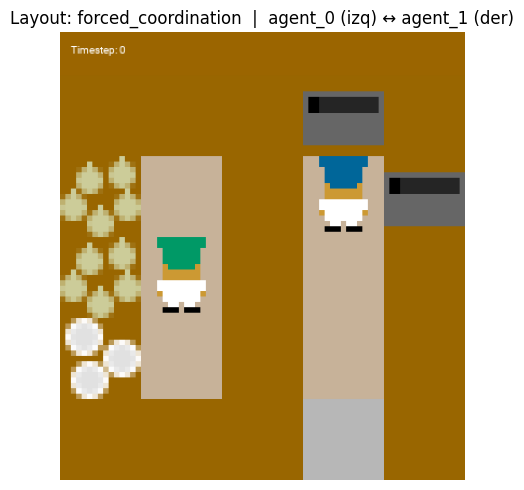

Frame shape: (415, 375, 3)   (H, W, 3 canales RGB)
Para servir una sopa: 3 cebollas pasadas + 1 plato pasado, todo a través del mostrador.


In [3]:
# Render del estado inicial del layout para verlo en el notebook
_env = OvercookedMultiAgentEnv()
_env.reset(seed=SEED)
_frame = _env.render()

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(_frame)
ax.set_title(f"Layout: {LAYOUT_NAME}  |  agent_0 (izq) ↔ agent_1 (der)")
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Frame shape: {_frame.shape}   (H, W, 3 canales RGB)")
print("Para servir una sopa: 3 cebollas pasadas + 1 plato pasado, todo a través del mostrador.")


## 4. Configuración de MAPPO

MAPPO en RLlib se construye con `PPOConfig` + `multi_agent(...)` apuntando todas las políticas a una misma red compartida (*parameter sharing*).

Todos los hiperparámetros viven en un único dict `HYPERPARAMS` para que sea trivial experimentar.

| Categoría | Parámetros | Efecto |
|---|---|---|
| Rollouts | `train_batch_size`, `num_env_runners`, `rollout_fragment_length` | Cuántos datos se recogen por iteración |
| Optimización | `lr`, `num_epochs`, `minibatch_size`, `grad_clip` | Velocidad y estabilidad del SGD |
| PPO | `clip_param`, `gamma`, `lambda_`, `vf_loss_coeff`, `entropy_coeff` | Forma del objetivo (sesgo/varianza, exploración) |

**Notas sobre `forced_coordination`**: requiere muchas iteraciones porque el reward sparse aparece sólo tras ~30 pasos coordinados. Por eso subimos `entropy_coeff` ligeramente (más exploración) y damos un horizonte de aprendizaje generoso (80 iter ≈ 1.6 M de pasos).


In [9]:
# =====================================================================
# Hiperparámetros de MAPPO. Modifica aquí para experimentar.
# =====================================================================
HYPERPARAMS = {
    # ---------- Entorno ----------
    "layout_name": LAYOUT_NAME,
    "horizon":     HORIZON,

    # ---------- Rollouts ----------
    "num_env_runners":         4,        # workers paralelos
    "rollout_fragment_length": 400,      # = HORIZON -> 1 episodio completo por worker
    "train_batch_size":        8000,     # muestras totales por iteración

    # ---------- Optimización ----------
    "lr":             3e-4,
    "num_epochs":     8,
    "minibatch_size": 1000,
    "grad_clip":      0.5,

    # ---------- Objetivo PPO ----------
    "gamma":         0.99,
    "lambda_":       0.95,
    "clip_param":    0.2,
    "vf_loss_coeff": 0.5,
    "entropy_coeff": 0.02,               # ligeramente alto: incentiva exploración

    # ---------- Recursos ----------
    "num_gpus":  1,                      # T4 disponible en Colab
    "framework": "torch",

    # ---------- Entrenamiento ----------
    "num_iterations": 80,
}


def build_mappo_config(hp=HYPERPARAMS):
    """PPO multiagente con parameter sharing (= MAPPO con red compartida)."""
    # Obs/act spaces de la política compartida (las de un único agente).
    sample_env = OvercookedMultiAgentEnv({"layout_name": hp["layout_name"],
                                          "horizon":     hp["horizon"]})
    obs_space = sample_env.observation_space["agent_0"]
    act_space = sample_env.action_space["agent_0"]

    policies = {"shared_policy": (None, obs_space, act_space, {})}

    def policy_mapping_fn(agent_id, *args, **kwargs):
        # Ambos agentes -> misma política (parameter sharing).
        return "shared_policy"

    config = (
        PPOConfig()
        .api_stack(
            enable_rl_module_and_learner=False,
            enable_env_runner_and_connector_v2=False,
        )
        .environment(
            env="overcooked_multiagent",
            env_config={"layout_name": hp["layout_name"], "horizon": hp["horizon"]},
        )
        .framework(hp["framework"])
        .multi_agent(
            policies=policies,
            policy_mapping_fn=policy_mapping_fn,
            policies_to_train=["shared_policy"],
        )
        .training(
            train_batch_size=hp["train_batch_size"],
            num_sgd_iter=hp["num_epochs"],          
            sgd_minibatch_size=hp["minibatch_size"], 
            
            lr=hp["lr"],
            gamma=hp["gamma"],
            lambda_=hp["lambda_"],
            clip_param=hp["clip_param"],
            entropy_coeff=hp["entropy_coeff"],
            vf_loss_coeff=hp["vf_loss_coeff"],
            grad_clip=hp["grad_clip"],
            # Obs es (5,5,26). 2 capas conv 3x3 stride 1: 5 -> 3 -> 1, output 1x1x64 -> MLP.
            model={
                "conv_filters": [[32, [3, 3], 1], [64, [3, 3], 1]],
                "post_fcnet_hiddens": [256, 256],
                "post_fcnet_activation": "tanh",
            },
        )
        .env_runners(
            num_env_runners=hp["num_env_runners"],
            rollout_fragment_length=hp["rollout_fragment_length"],
        )
        .resources(num_gpus=hp["num_gpus"])
    )
    return config


mappo_config = build_mappo_config()
print("MAPPO config lista.")
print(f"  Layout            : {HYPERPARAMS['layout_name']}")
print(f"  Iteraciones       : {HYPERPARAMS['num_iterations']}")
print(f"  Workers paralelos : {HYPERPARAMS['num_env_runners']}")
print(f"  Batch  : {HYPERPARAMS['train_batch_size']} ")
print(f"  lr / clip / ent   : {HYPERPARAMS['lr']} / {HYPERPARAMS['clip_param']} / {HYPERPARAMS['entropy_coeff']}")
print(f"  GPU               : {HYPERPARAMS['num_gpus']}")
print( "  Parameter sharing : agent_0 y agent_1 -> shared_policy")


MAPPO config lista.
  Layout            : forced_coordination
  Iteraciones       : 80
  Workers paralelos : 4
  Batch  : 8000 
  lr / clip / ent   : 0.0003 / 0.2 / 0.02
  GPU               : 1
  Parameter sharing : agent_0 y agent_1 -> shared_policy


## 5. Entrenamiento

Cada iteración de `algo.train()`:
1. Recoge `train_batch_size` muestras desde los `num_env_runners` workers en paralelo.
2. Calcula ventajas con GAE (`gamma`, `lambda_`).
3. Actualiza la **política compartida** con `num_epochs` épocas de PPO sobre minibatches, recortando el ratio según `clip_param`.

Guardamos el reward medio por episodio para dibujar la curva de aprendizaje. En `forced_coordination` la baseline aleatoria está cerca de 0 (ambos cocineros vagando sin tocarse), y MAPPO debería subir a varias decenas en ~80 iteraciones.

> Tiempo aproximado en Colab + T4: **20–30 minutos**.


In [ ]:
import shutil
import subprocess


def _extract_metric(result, *keys, default=float("nan")):
    """Busca una métrica en estructura anidada (env_runners.*, sampler_results.*, raíz)."""
    pools = [result, result.get("env_runners", {}), result.get("sampler_results", {})]
    for pool in pools:
        for k in keys:
            if k in pool and pool[k] is not None:
                return pool[k]
    return default


def _start_ray_clean():
    """Arranca Ray limpiando procesos zombies y /tmp/ray previos.

    En Colab es habitual ver `RuntimeError: Timed out waiting for file
    /tmp/ray/.../gcs_server_port_...` cuando hay un Ray previo a medio
    apagar o cuando no se reinició el runtime tras instalar ray==2.32.
    Esta función lo evita.
    """
    if ray.is_initialized():
        ray.shutdown()
    # Limpieza agresiva (silenciosa si no hay nada que limpiar)
    subprocess.run(["pkill", "-9", "-f", "ray"],     check=False,
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    subprocess.run(["rm", "-rf", "/tmp/ray"],        check=False,
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    ray.init(
        ignore_reinit_error=True,
        log_to_driver=False,
        include_dashboard=False,
        _temp_dir="/tmp/ray_session",      # carpeta nueva -> sin sockets viejos
    )
    print("Ray inicializado. Recursos:", ray.cluster_resources())


_start_ray_clean()

# IMPORTANTE: registrar el entorno DESPUÉS de ray.init para que llegue al GCS
# y los workers (procesos separados) lo encuentren.
register_env("overcooked_multiagent", env_creator)

algo = mappo_config.build()

learning_curve = []
print(f"\nEntrenando MAPPO durante {HYPERPARAMS['num_iterations']} iteraciones...\n")
print(f"{'iter':>4} | {'rew_mean':>9} | {'rew_max':>8} | {'ep_len':>6}")
print("-" * 42)
for i in range(HYPERPARAMS["num_iterations"]):
    result = algo.train()
    rmean = _extract_metric(result, "episode_return_mean", "episode_reward_mean")
    rmax  = _extract_metric(result, "episode_return_max",  "episode_reward_max")
    elen  = _extract_metric(result, "episode_len_mean")
    learning_curve.append({"iter": i + 1, "reward": rmean,
                           "reward_max": rmax, "length": elen})
    print(f"{i+1:>4} | {rmean:>9.3f} | {rmax:>8.3f} | {elen:>6.1f}")

# Checkpoint final
checkpoint_dir = os.path.abspath("./mappo_checkpoint")
if os.path.exists(checkpoint_dir):
    shutil.rmtree(checkpoint_dir)
ckpt = algo.save(checkpoint_dir)
print(f"\nCheckpoint -> {checkpoint_dir}")

# Curva de aprendizaje
iters   = [x["iter"]   for x in learning_curve]
rewards = [x["reward"] for x in learning_curve]
plt.figure(figsize=(9, 4))
plt.plot(iters, rewards, marker="o", linewidth=2, color="tab:blue")
plt.title("Curva de aprendizaje MAPPO — forced_coordination")
plt.xlabel("Iteración")
plt.ylabel("Recompensa media por episodio")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Evaluación cuantitativa y métricas de cooperación

Construimos `policy_fn(obs_dict) -> action_dict` envolviendo el algoritmo entrenado. Esta función es la **ejecución descentralizada**: aunque ambos agentes compartan los mismos pesos, cada uno decide solo con su observación local.

Comparamos contra la baseline aleatoria midiendo:

- **Reward total medio** (shaping incluido).
- **Sopas entregadas** (señal "sparse" de cooperación efectiva = nº de veces que aparece +20 en el reward).
- **Desviación estándar** entre episodios.

En `forced_coordination` la métrica más expresiva es "sopas entregadas": la política aleatoria entregará ~0 prácticamente siempre.


In [ ]:
def make_trained_policy_fn(algo, policy_id="shared_policy", deterministic=True):
    """Envuelve el algoritmo entrenado en una callable obs_dict -> action_dict."""
    def policy_fn(obs_dict):
        return {
            agent: int(algo.compute_single_action(
                observation=obs,
                policy_id=policy_id,
                explore=not deterministic,
            ))
            for agent, obs in obs_dict.items()
        }
    return policy_fn


def evaluate_policy(policy_fn, n_episodes=10, layout_name=HYPERPARAMS["layout_name"]):
    """Evalúa una policy_fn. None -> aleatoria.

    Devuelve dict con reward medio (shaping incl.) y sopas entregadas medias.
    """
    env = OvercookedMultiAgentEnv({"layout_name": layout_name, "horizon": HORIZON})
    ep_rewards, ep_soups = [], []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=SEED + ep)
        done = False
        total_r, soups = 0.0, 0
        while not done:
            actions = (policy_fn(obs) if policy_fn is not None
                       else {a: env.action_space[a].sample() for a in env.AGENT_IDS})
            obs, rewards, terms, truncs, infos = env.step(actions)
            total_r += sum(rewards.values()) / 2.0
            # +20 por sopa entregada (lado sparse del reward); /20 = nº sopas en ese paso
            soups += int(round(infos["agent_0"]["sparse_reward"] / 20.0))
            done = terms["__all__"] or truncs["__all__"]
        ep_rewards.append(total_r)
        ep_soups.append(soups)
    return {
        "reward_mean": float(np.mean(ep_rewards)),
        "reward_std":  float(np.std(ep_rewards)),
        "soups_mean":  float(np.mean(ep_soups)),
        "soups_std":   float(np.std(ep_soups)),
    }


trained_policy_fn = make_trained_policy_fn(algo)
rnd   = evaluate_policy(None,              n_episodes=10)
mappo = evaluate_policy(trained_policy_fn, n_episodes=10)

print("Resultados sobre 10 episodios:")
print(f"{'':<10} {'reward':>16} {'sopas/episodio':>18}")
print("-" * 46)
print(f"{'Aleatoria':<10} {rnd['reward_mean']:>8.2f} ± {rnd['reward_std']:>5.2f}   "
      f"{rnd['soups_mean']:>6.2f} ± {rnd['soups_std']:.2f}")
print(f"{'MAPPO':<10} {mappo['reward_mean']:>8.2f} ± {mappo['reward_std']:>5.2f}   "
      f"{mappo['soups_mean']:>6.2f} ± {mappo['soups_std']:.2f}")
print()
if rnd["soups_mean"] < 0.01 and mappo["soups_mean"] > 0:
    print(f">>> MAPPO entrega {mappo['soups_mean']:.1f} sopas por episodio frente a 0 de la baseline aleatoria.")
    print(">>> Esa diferencia ES la cooperación emergente: ningún agente puede entregar solo.")


## 7. Renderizado a MP4 — comparación visual

Generamos **dos vídeos** sobre el mismo layout y la misma semilla:

1. `overcooked_random.mp4` — baseline aleatoria (los cocineros se mueven sin sentido).
2. `overcooked_mappo.mp4` — política entrenada (deberías verlos pasarse cebollas y servir sopas).

La función `rollout_to_mp4` acepta cualquier `policy_fn(obs) -> actions`, captura los frames RGB del `StateVisualizer` y los escribe con `imageio + ffmpeg`.

---

### Conclusiones — qué hemos visto
- **Implementación del MAS**: dos agentes con observación local, política compartida, recompensa cooperativa.
- **MAPPO en acción**: PPO multiagente con CTDE — crítico entrenado con la experiencia conjunta, política ejecutada de forma independiente por cada agente.
- **Coordinación emergente** en `forced_coordination`: sin habérseles dicho cómo cooperar, los agentes aprenden el protocolo `cebolla→mostrador→olla→sopa→servir` a través del *reward shaping* + recompensa global compartida.


In [ ]:
def rollout_to_mp4(policy_fn=None, output_path="overcooked_rollout.mp4",
                   fps=8, max_steps=None, layout_name=HYPERPARAMS["layout_name"], seed=SEED):
    """Ejecuta un episodio y lo guarda como MP4. policy_fn=None -> aleatoria."""
    env = OvercookedMultiAgentEnv({"layout_name": layout_name, "horizon": HORIZON})
    obs, _ = env.reset(seed=seed)
    frames = [env.render()]
    steps = max_steps or env.horizon
    done, t, total, soups = False, 0, 0.0, 0
    while not done and t < steps:
        actions = (policy_fn(obs) if policy_fn is not None
                   else {a: env.action_space[a].sample() for a in env.AGENT_IDS})
        obs, rewards, terms, truncs, infos = env.step(actions)
        total += sum(rewards.values()) / 2.0
        soups += int(round(infos["agent_0"]["sparse_reward"] / 20.0))
        frames.append(env.render())
        done = terms["__all__"] or truncs["__all__"]
        t += 1

    writer = imageio.get_writer(output_path, fps=fps, codec="libx264",
                                quality=8, macro_block_size=1)
    for f in frames:
        writer.append_data(f.astype(np.uint8))
    writer.close()
    print(f"  {os.path.basename(output_path):<22} frames={len(frames):>3}  "
          f"pasos={t:>3}  reward={total:6.2f}  sopas={soups}")
    return output_path


print("Generando vídeos de comparación...\n")
rollout_to_mp4(policy_fn=None,              output_path="overcooked_random.mp4")
rollout_to_mp4(policy_fn=trained_policy_fn, output_path="overcooked_mappo.mp4")
print("\nListo. Abre los dos MP4 lado a lado para comparar el comportamiento.")
print("- overcooked_random.mp4 : cocineros sin coordinación (baseline)")
print("- overcooked_mappo.mp4  : cocineros entrenados con MAPPO -> cooperación emergente")
